In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "paths.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing config/paths.json")

REPO_ROOT = find_repo_root()
UTILS_DIR = REPO_ROOT / "code" / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

from project_paths import ensure_project_dirs, load_project_paths

PATHS = ensure_project_dirs(load_project_paths(REPO_ROOT))

import pandas as pd
import re
import numpy as np

participants_df = pd.read_csv(PATHS["participants_file"], sep="\t")
out_df = pd.read_csv(PATHS["other_study_data_dir"] / "blood_concentrations.tsv", sep="\t")
out_dir = PATHS["pk_pd_figures_root"]


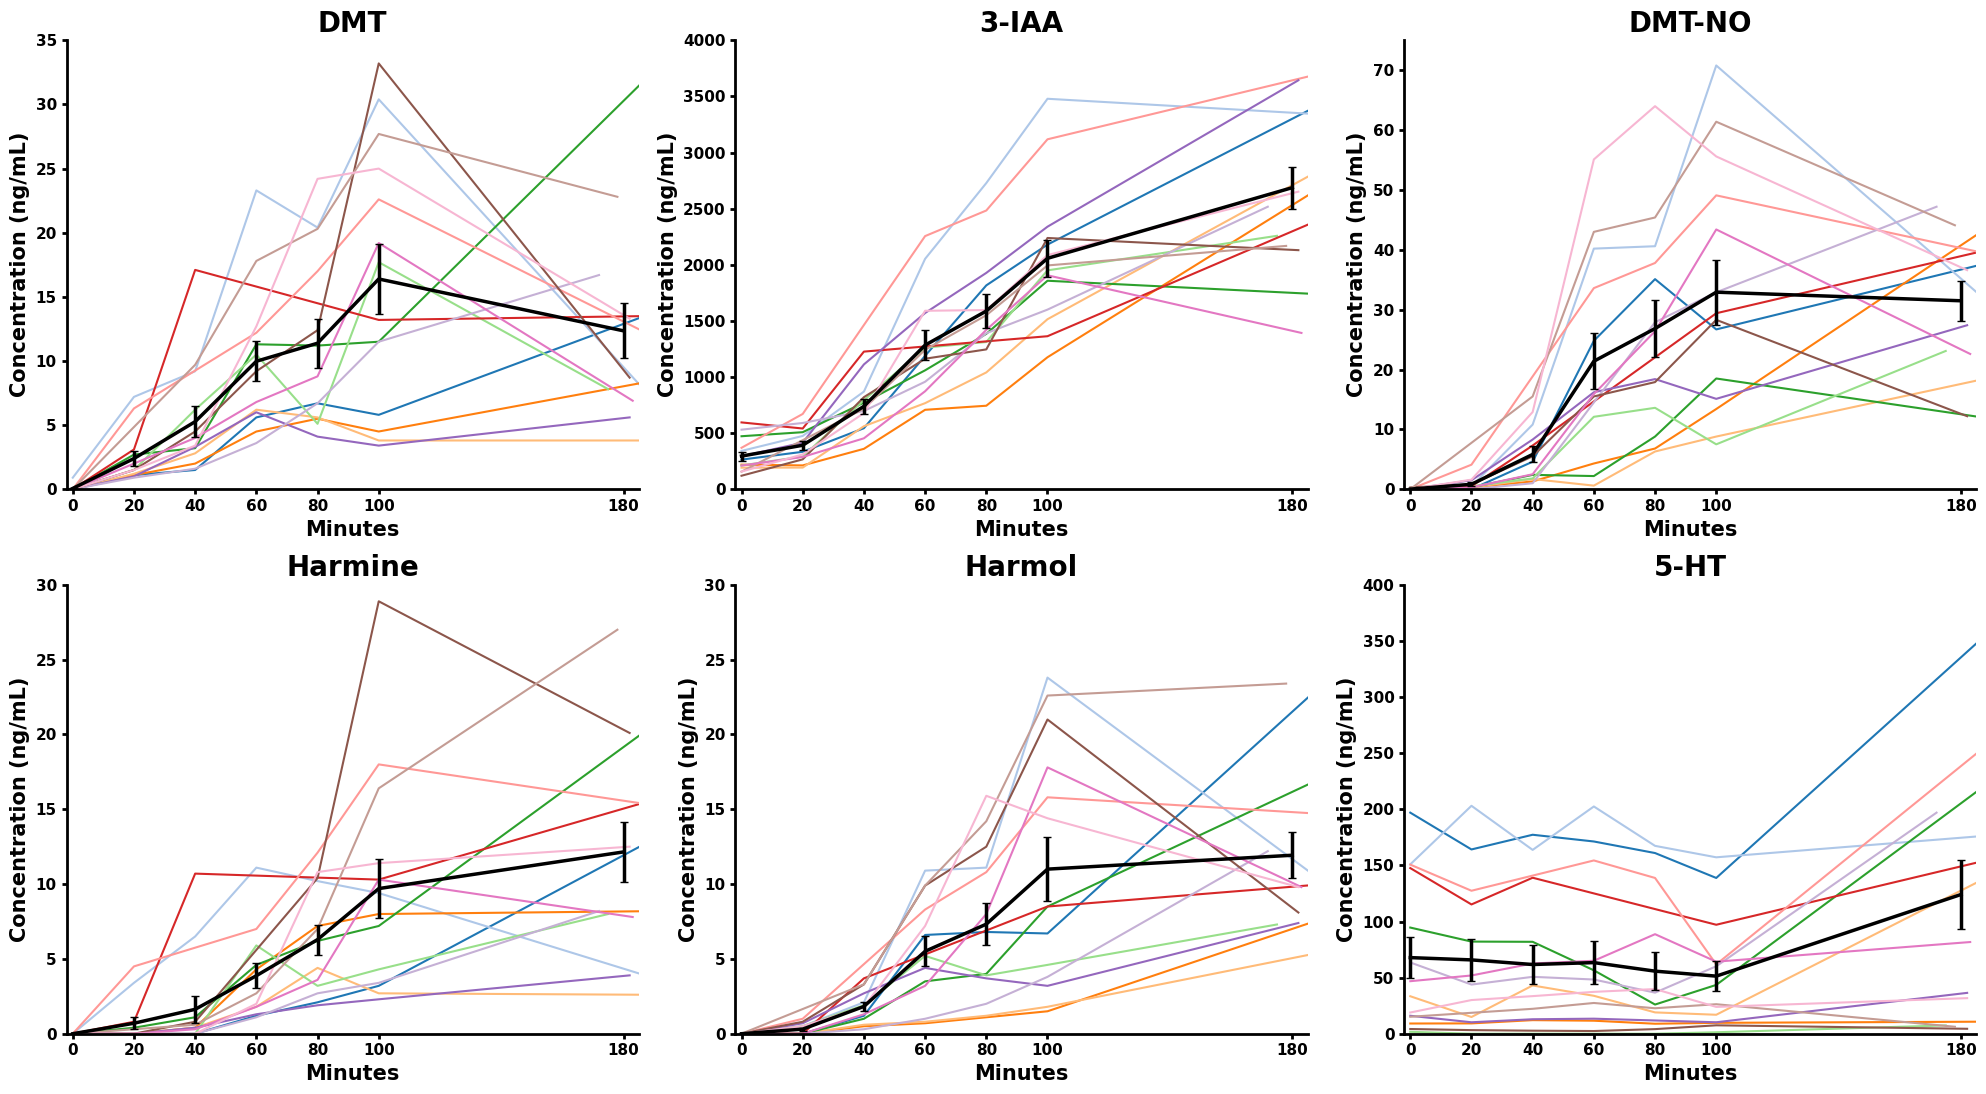

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib
import numpy as np

# Load the previously created DataFrame (out_df)
# Pivot the data to get the metabolite concentrations in a wide format
df_pivot = out_df.pivot_table(index=['participant_id', 'Timepoint', 'Timepoint_actual'], 
                              columns='metabolite', 
                              values='Contration [ng/mL]').reset_index()

metabolites = ["DMT", "3-IAA", "DMT-NO", "Harmine", "Harmol", "5-HT"]

# Specify y-axis limits
y_lims = {
    "DMT": [0, 35],
    "3-IAA": [0, 4000],
    "DMT-NO": [0, 75],
    "Harmine": [0, 30],
    "Harmol": [0, 30],
    "5-HT": [00, 400]
}

# Calculate the mean and SEM
grouped_data = df_pivot.groupby(["Timepoint", "participant_id"])[metabolites].mean().reset_index()
means = grouped_data.groupby(["Timepoint"])[metabolites].mean().reset_index()
sems = grouped_data.groupby(["Timepoint"])[metabolites].sem().reset_index()

# Set the value to 0 if the timepoint 0 contains no values for a metabolite
for metabolite in metabolites:
    if means.loc[means["Timepoint"] == 0, metabolite].isna().all():
        means.loc[means["Timepoint"] == 0, metabolite] = 0
        sems.loc[sems["Timepoint"] == 0, metabolite] = 0


def plot_individual_metabolites(df_pivot, means, sems, metabolites, y_lims):
    participant_ids = df_pivot['participant_id'].unique()
    color_map = matplotlib.colormaps['tab20']
    participant_colors = {pid: color_map(i) for i, pid in enumerate(participant_ids)}

    fig, axs = plt.subplots(2, 3, figsize=(20, 12))
    
    for ax, metabolite in zip(axs.ravel(), metabolites):
        for pid in participant_ids:
            sub_data = df_pivot[df_pivot['participant_id'] == pid]
            ax.plot(sub_data['Timepoint_actual'], sub_data[metabolite],
                    label=pid, color=participant_colors[pid], alpha=1)
        
        # Overlay mean ± SEM
        ax.errorbar(means['Timepoint'], means[metabolite], yerr=sems[metabolite],
                    label='Mean', color='black', linewidth=2.5, capsize=3)

        ax.set_title(metabolite, weight='bold', size=20)
        ax.set_xlabel('Minutes', weight='bold', size=15)
        ax.set_ylabel('Concentration (ng/mL)', weight='bold', size=15)
        ax.set_ylim(y_lims[metabolite])
        ax.grid(False)
        ax.set_xticks(sorted(means["Timepoint"].unique()))
        ax.set_xlim(-2, 185)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
        ax.tick_params(axis='both', labelsize=11, width=2)
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

fig = plot_individual_metabolites(df_pivot, means, sems, metabolites, y_lims)
plt.savefig(f"{out_dir}/plasma_individual_metabolite_concentrations.png", dpi=600, bbox_inches='tight')
plt.show()

In [3]:

### Load the CMRglc data
cmrglc_patlak_kinfitr_file = PATHS["kinfitr_output_root"] / "02_Outcomes" / "03_model_outcomes" / "Patlak_outcomes.tsv"
cmrglc_patlak_data = pd.read_csv(cmrglc_patlak_kinfitr_file, sep="\t")
cmrglc_for_correlation = cmrglc_patlak_data[(cmrglc_patlak_data['condition'] == 'Verum') & (cmrglc_patlak_data['Region'] == 'whole_brain')]
cmrglc_whole_brain = cmrglc_patlak_data[cmrglc_patlak_data['Region'] == 'whole_brain']
cmrglc_pivot = cmrglc_whole_brain.pivot(index='sub', columns='condition', values='CMRglc')
cmrglc_pivot['delta_CMRglc'] = cmrglc_pivot['Verum'] - cmrglc_pivot['Placebo']
cmrglc_for_correlation = cmrglc_for_correlation.merge(
    cmrglc_pivot['delta_CMRglc'],
    left_on='sub',
    right_index=True,
    how='left'
)

### Load the AUC data
auc_df_combined = pd.read_csv(PATHS["nca_output_root"] / 'DHTP_PKdata_preprocessed_V4_ng_ml_NCA_AUC_last_selected.csv')
auc_df_combined = auc_df_combined.pivot(index='participant_id', columns='Metabolite', values='Value').reset_index()
auc_df_combined = auc_df_combined.rename(columns={'DMT': 'AUC_DMT', 'Harmine': 'AUC_Harmine'})
auc_df_combined['sub'] = auc_df_combined['participant_id'].str.replace('sub-', '').str.upper()

out_df_mean_intensity = out_df[(out_df["metabolite"] == "DMT") & (out_df["Timepoint"].isin([100, 180]))].copy()
out_df_mean_intensity = out_df_mean_intensity.groupby("participant_id")["Contration [ng/mL]"].mean().reset_index()
out_df_mean_intensity = out_df_mean_intensity.rename(columns={"Contration [ng/mL]": "mean_DMT_concentration_100_180"})
out_df_mean_intensity['sub'] = out_df_mean_intensity['participant_id'].str.replace('sub-', '').str.upper()


AUClast (DMT) vs. CMRglc correlation: r = 0.3512, p = 0.2183


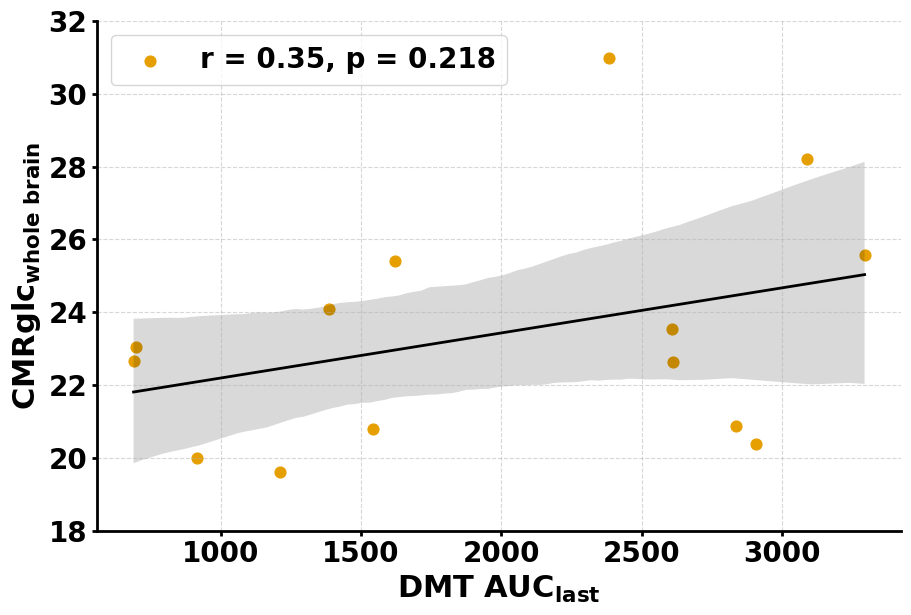

AUClast (Harmine) vs. CMRglc correlation: r = 0.6156, p = 0.0191


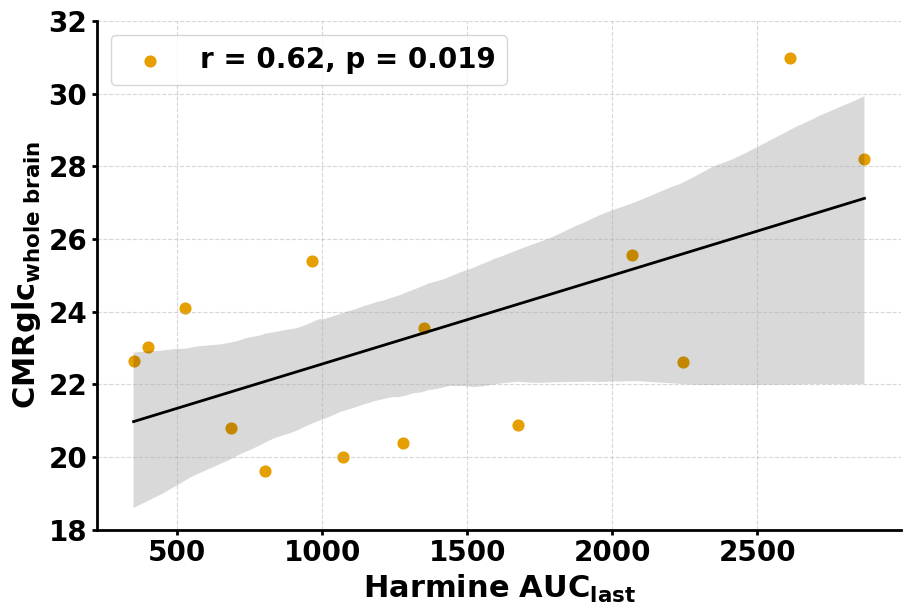

AUClast (DMT) vs. delta_CMRglc correlation: r = 0.1900, p = 0.5154


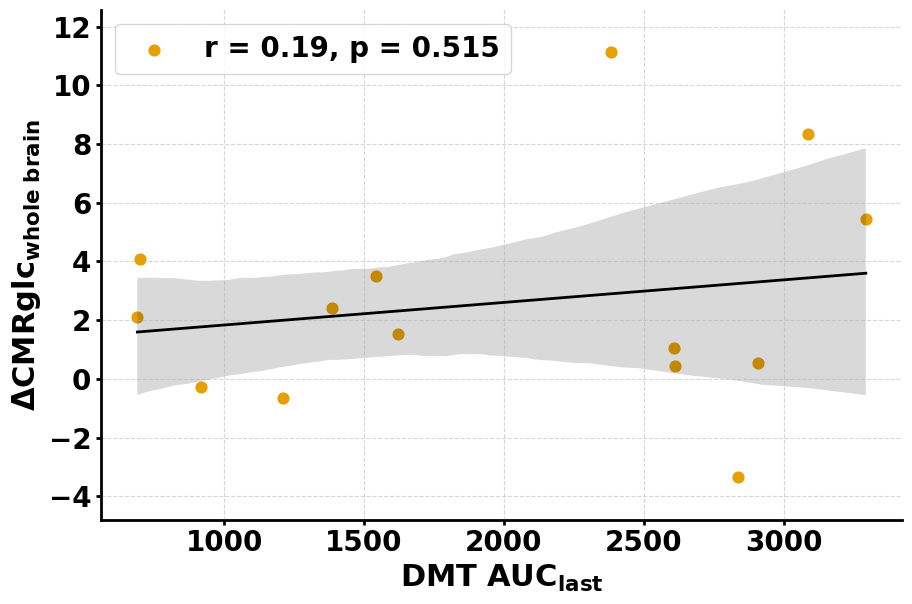

AUClast (Harmine) vs. delta_CMRglc correlation: r = 0.4808, p = 0.0818


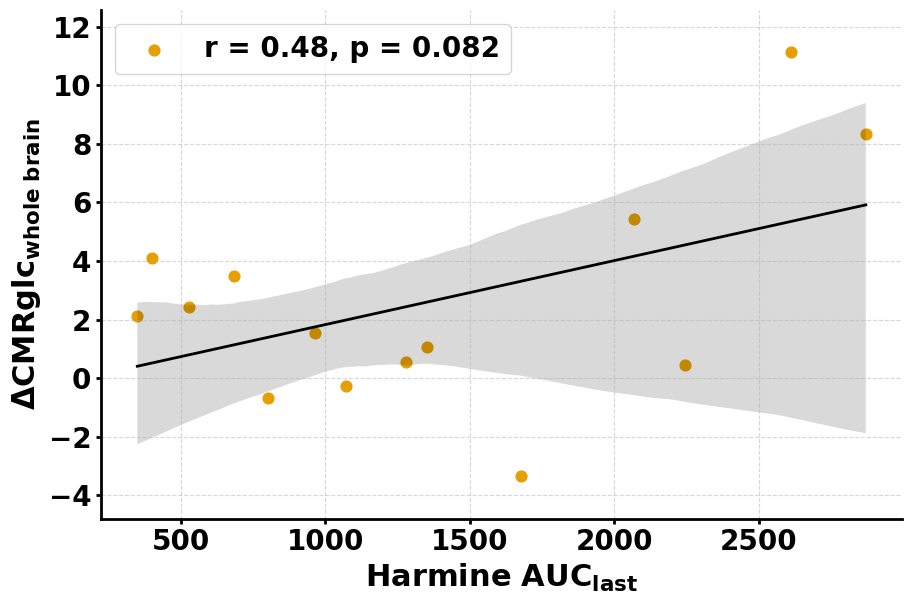

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_auc_vs_cmrglc(
    auc_column,
    auc_label,
    cmrglc_df,
    auc_df,
    y_column,
    y_label,
    y_limits,
    output_prefix,
):
    merged_df = pd.merge(cmrglc_df, auc_df[["sub", auc_column]], on="sub")
    merged_df = merged_df.dropna(subset=[auc_column, y_column])

    x_vals = merged_df[auc_column]
    y_vals = merged_df[y_column]

    corr, p_value = pearsonr(x_vals, y_vals)
    print(
        f"AUClast ({auc_label}) vs. {y_column} correlation: "
        f"r = {corr:.4f}, p = {p_value:.4f}"
    )

    plt.figure(figsize=(9, 6))
    sns.regplot(
        x=x_vals,
        y=y_vals,
        scatter_kws={'alpha': 1, 's': 60},
        line_kws={'color': 'black', 'lw': 2},
        ci=95,
        color='#E69F00'
    )
    sns.despine()
    plt.gca().spines['left'].set_linewidth(2)
    plt.gca().spines['bottom'].set_linewidth(2)
    plt.xlabel(r"$\mathbf{" + auc_label + r"\ AUC_{last}}$", fontsize=22)
    plt.ylabel(y_label, fontsize=22)
    plt.legend([f'r = {corr:.2f}, p = {p_value:.3f}'], loc='upper left', prop={'weight': 'bold', 'size': 20})
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    if y_limits is not None:
        plt.ylim(y_limits)
    else:
        y_min, y_max = y_vals.min(), y_vals.max()
        padding = max((y_max - y_min) * 0.1, 0.5)
        plt.ylim(y_min - padding, y_max + padding)
    plt.tick_params(axis='both', labelsize=20, width=2)
    plt.setp(plt.gca().get_xticklabels(), fontweight='bold')
    plt.setp(plt.gca().get_yticklabels(), fontweight='bold')
    plt.savefig(
        f"{out_dir}/{output_prefix}_with_AUC_{auc_label}_concentrations.png",
        dpi=600,
        bbox_inches='tight'
    )
    plt.show()

plot_configs = [
    {
        "y_column": "CMRglc",
        "y_label": r"$\mathbf{CMRglc}_{\mathbf{whole\ brain}}$",
        "y_limits": (18, 32),
        "output_prefix": "correlations_CMRglc",
    },
    {
        "y_column": "delta_CMRglc",
        "y_label": r"$\mathbf{\Delta CMRglc}_{\mathbf{whole\ brain}}$",
        "y_limits": None,
        "output_prefix": "correlations_delta_CMRglc",
    },
]

for plot_config in plot_configs:
    plot_auc_vs_cmrglc("AUC_DMT", "DMT", cmrglc_for_correlation, auc_df_combined, **plot_config)
    plot_auc_vs_cmrglc("AUC_Harmine", "Harmine", cmrglc_for_correlation, auc_df_combined, **plot_config)
